# 01 EDA - lokalna analiza

Ovaj notebook se izvodi lokalno s `requirements-local.txt`. Ne koristi stari Azure environment jer je on namijenjen Azure ML treningu/deploymentu.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/student_depression_dataset.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [5]:
df.duplicated().sum()

0

Depression
0    11565
1    16336
Name: count, dtype: int64
Depression
0    0.414501
1    0.585499
Name: proportion, dtype: float64


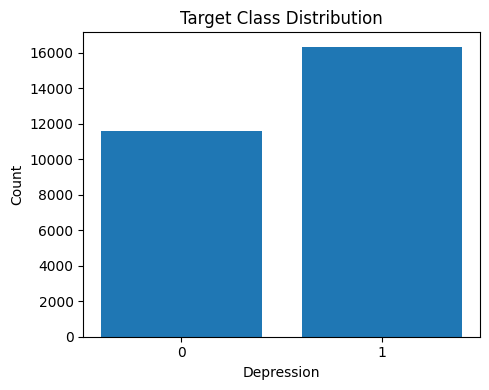

In [6]:
target = "Depression"
class_counts = df[target].value_counts().sort_index()
class_ratio = df[target].value_counts(normalize=True).sort_index()
print(class_counts)
print(class_ratio)

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Depression")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

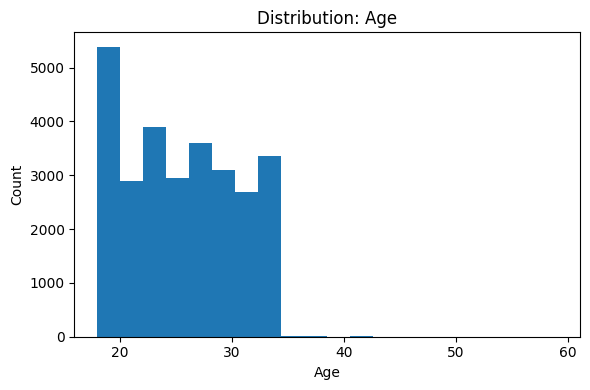

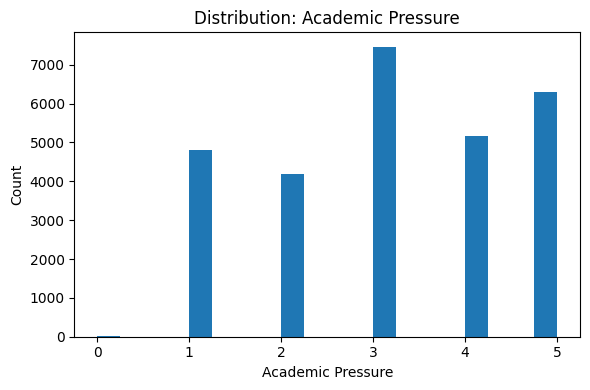

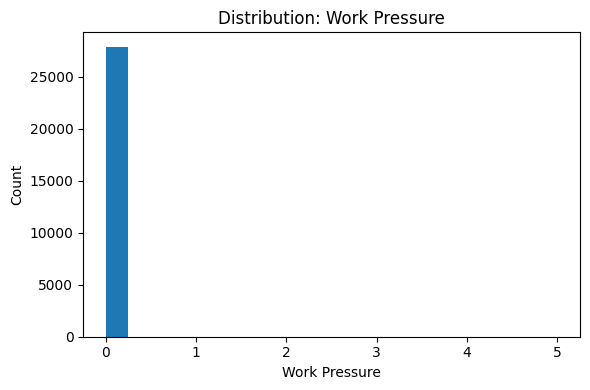

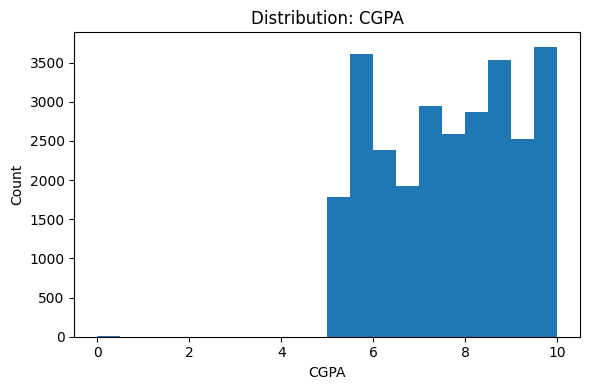

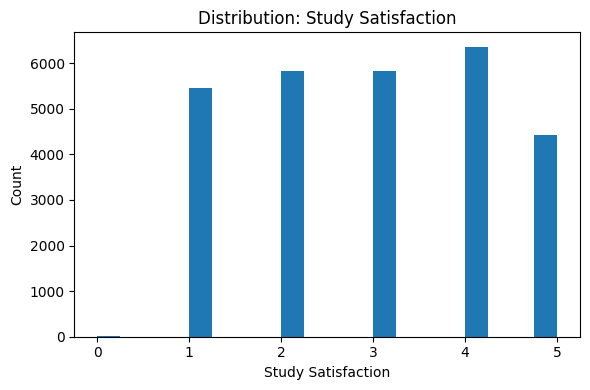

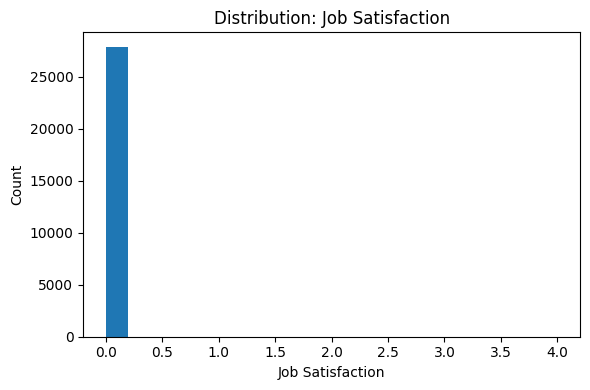

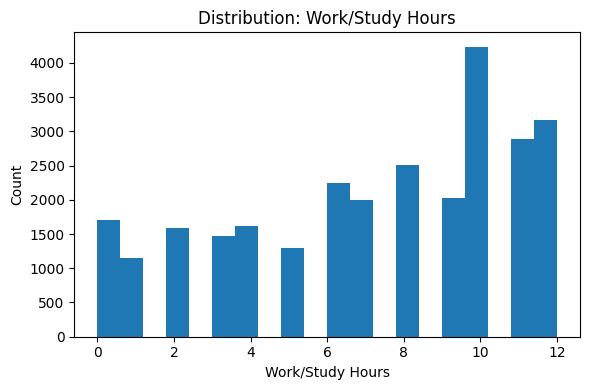

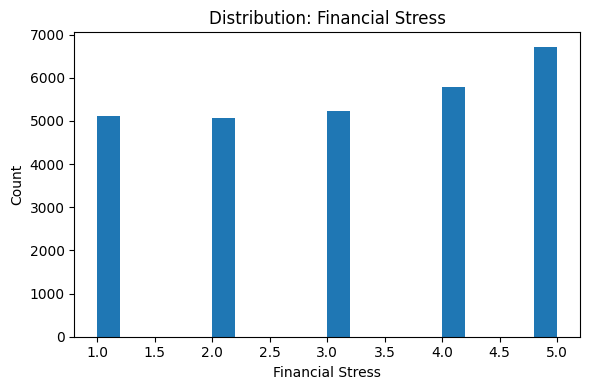

In [7]:
numeric_features = [
    "Age", "Academic Pressure", "Work Pressure", "CGPA", "Study Satisfaction",
    "Job Satisfaction", "Work/Study Hours", "Financial Stress"
]
existing_numeric = [c for c in numeric_features if c in df.columns]

for col in existing_numeric:
    plt.figure(figsize=(6, 4))
    plt.hist(pd.to_numeric(df[col], errors="coerce").dropna(), bins=20)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

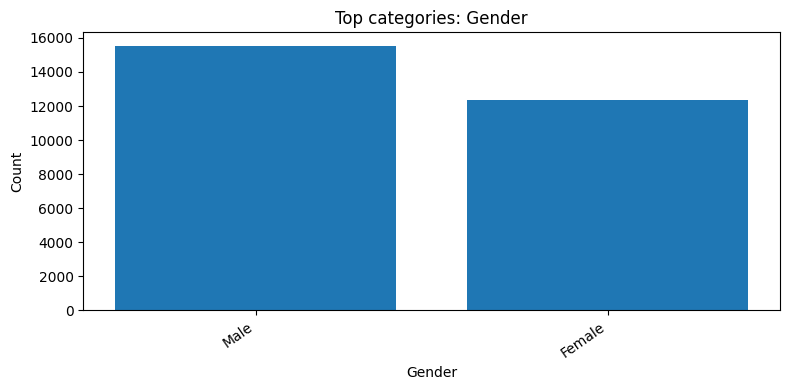

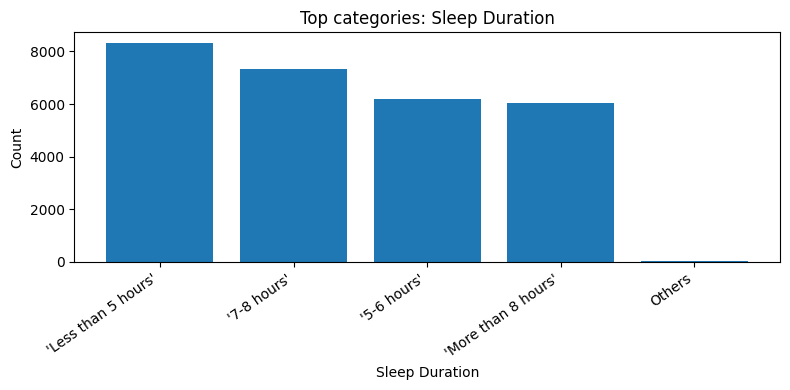

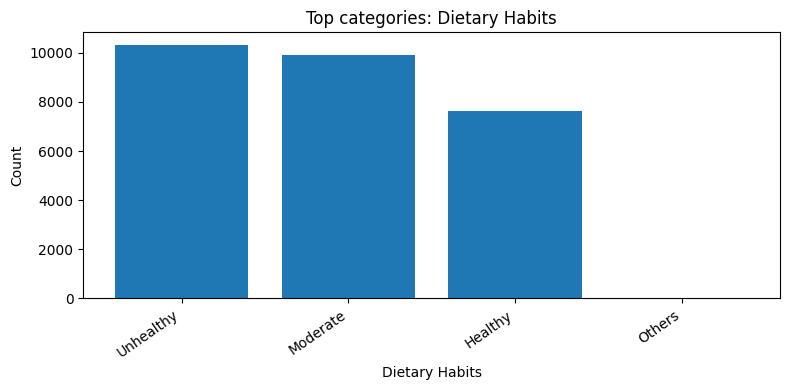

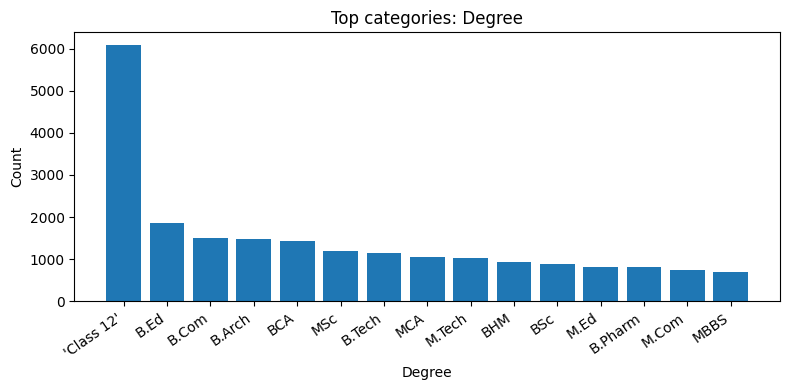

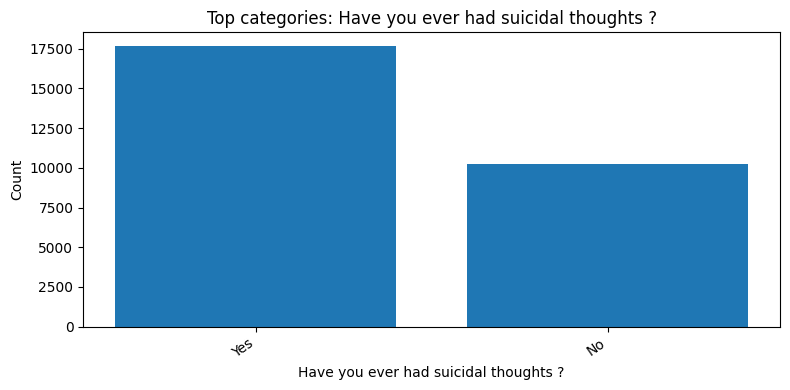

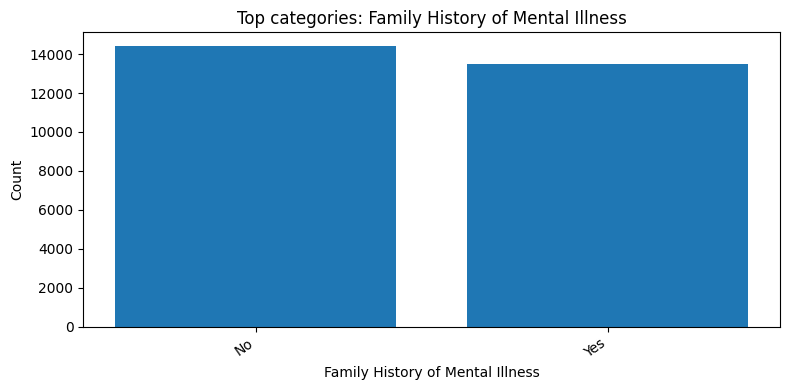

In [8]:
categorical_features = [
    "Gender", "Sleep Duration", "Dietary Habits", "Degree",
    "Have you ever had suicidal thoughts ?", "Family History of Mental Illness"
]
existing_categorical = [c for c in categorical_features if c in df.columns]

for col in existing_categorical:
    counts = df[col].astype(str).value_counts().head(15)
    plt.figure(figsize=(8, 4))
    plt.bar(counts.index, counts.values)
    plt.title(f"Top categories: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

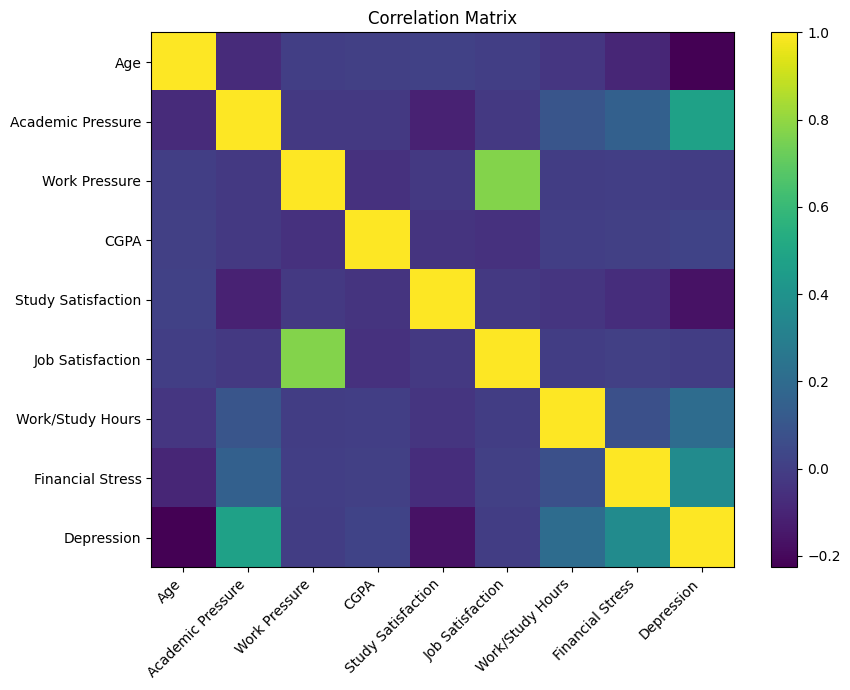

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
Age,1.000000,-0.075803,0.002015,0.005056,0.009235,-0.000432,-0.032928,-0.095026,-0.226422
Academic Pressure,-0.075803,1.000000,-0.022231,-0.022239,-0.110988,-0.024945,0.095970,0.151706,0.474835
Work Pressure,0.002015,-0.022231,1.000000,-0.050896,-0.021145,0.770652,-0.005468,0.001883,-0.003351
CGPA,0.005056,-0.022239,-0.050896,1.000000,-0.044062,-0.053631,0.002604,0.005885,0.022210
Study Satisfaction,0.009235,-0.110988,-0.021145,-0.044062,1.000000,-0.021907,-0.036441,-0.065107,-0.167971
Job Satisfaction,-0.000432,-0.024945,0.770652,-0.053631,-0.021907,1.000000,-0.005222,0.005248,-0.003482
Work/Study Hours,-0.032928,0.095970,-0.005468,0.002604,-0.036441,-0.005222,1.000000,0.075283,0.208563
Financial Stress,-0.095026,0.151706,0.001883,0.005885,-0.065107,0.005248,0.075283,1.000000,0.363591
Depression,-0.226422,0.474835,-0.003351,0.022210,-0.167971,-0.003482,0.208563,0.363591,1.000000


In [9]:
corr_df = df[existing_numeric + [target]].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr